# Stage 4: Validation and Fitting

## Goal:

This notebook tests wether the model-fitting procedure is meaningful before applying it to real empirical data. 

We:
1. Simulate network activity using known ground-truth values of *K* and *lambda*
2. Add measurement noise
3. Compute a synthetic empirical PLI matrix
4. Fit K and lambda by maximising Pearson correlation
5. Visualise the fit quality and parameter recovery

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import pearsonr


## Hopf Network Model

We use a network of **coupled Hopf oscillators**, where:
- Each node represents a brain region (78 regions from a parcellation atlas)
- Nodes are coupled through a structural connectivity (SC) matrix *W*, derived from diffusion MRI tractography
- Each node follows a normal form Hopf bifurcation:

$$\dot{x}_i = x_i(\lambda - r_i^2) - \omega_i y_i + K \tanh\left(C \sum_j W_{ij} x_j\right)$$
$$\dot{y}_i = y_i(\lambda - r_i^2) + \omega_i x_i$$

where:
- $\lambda$ controls **local excitability** (negative → damped oscillation; positive → limit cycle)
- $K$ is the **global coupling strength**
- $\omega_i = 2\pi f_i$ is the natural frequency of node $i$ (set to the empirical peak frequency)
- $C$ is a saturation constant (fixed at 1)

The two free parameters we fit are **$K$** and **$\lambda$**.


In [15]:
# -----------------------------
# Hopf model
# -----------------------------

def hopf_rhs(_t, state, _N, W, K, lam, C, omega):
    """
    Coupled Hopf oscillator ODE.
    State vector is [x1, y1, x2, y2, ..., xN, yN].
    """
    x = state[0::2]
    y = state[1::2]

    r2 = x**2 + y**2

    dx = x * (lam - r2) - omega * y + K * np.tanh(C * (W @ x))
    dy = y * (lam - r2) + omega * x

    out = np.empty_like(state)
    out[0::2] = dx
    out[1::2] = dy
    return out


def random_initial_conditions(N, rng=None, scale=0.1):
    """
    Random complex initial conditions for N nodes.
    """
    rng = np.random.default_rng(rng)
    return scale * (rng.standard_normal(N) + 1j * rng.standard_normal(N))


def simulate_hopf(N, W, K, lam, C, omega, z0=None,
                  t_total=20.0, t_discard=5.0, fs=250):
    """
    Simulate coupled Hopf oscillators.

    Returns
    -------
    t : array, shape (T,)
    x : array, shape (N, T)
    y : array, shape (N, T)
    """
    if z0 is None:
        z0 = random_initial_conditions(N, rng=42)
    elif np.isscalar(z0):
        z0 = np.full(N, z0, dtype=complex)

    state0 = np.empty(2 * N)
    state0[0::2] = np.real(z0)
    state0[1::2] = np.imag(z0)

    t_eval = np.arange(0.0, t_total, 1.0 / fs)

    sol = solve_ivp(
        hopf_rhs,
        t_span=(0.0, t_total),
        y0=state0,
        t_eval=t_eval,
        args=(N, W, K, lam, C, omega),
        rtol=1e-6,
        atol=1e-8,
    )

    state = sol.y
    x = state[0::2]
    y = state[1::2]
    t = sol.t

    keep = t >= t_discard
    return t[keep], x[:, keep], y[:, keep]

## Signal Processing and PLI

After simulation, node signals are:
1. **Band-pass filtered** (8–12 Hz, alpha band) using a 4th-order Butterworth filter
2. **Hilbert-transformed** to extract instantaneous phase
3. **PLI** (Phase Lag Index) is computed between all pairs of nodes:

$$\text{PLI}_{ij} = \left|\langle \text{sign}(\sin(\Delta\phi_{ij}(t))) \rangle_t\right|$$

PLI measures the asymmetry of the phase difference distribution — it is robust to volume conduction artefacts because it ignores zero-lag phase coupling.


In [16]:
# -----------------------------
# Signal processing and PLI
# -----------------------------

def bandpass_filter(signals, fs, f_lo=8.0, f_hi=12.0, order=4):
    """
    Band-pass filter node signals.

    Parameters
    ----------
    signals : array, shape (N, T)
    fs : float
        Sampling frequency
    """
    nyq = 0.5 * fs
    b, a = butter(order, [f_lo / nyq, f_hi / nyq], btype="band")
    return filtfilt(b, a, signals, axis=1)


def compute_pli(signals):
    """
    Compute Phase Lag Index (PLI) matrix from node signals.

    Parameters
    ----------
    signals : array, shape (N, T)

    Returns
    -------
    pli : array, shape (N, N)
    """
    phases = np.angle(hilbert(signals, axis=1))
    N = signals.shape[0]
    pli = np.zeros((N, N))

    for i in range(N):
        for j in range(i + 1, N):
            dphi = phases[i] - phases[j]
            pli_ij = np.abs(np.mean(np.sign(np.sin(dphi))))
            pli[i, j] = pli_ij
            pli[j, i] = pli_ij

    return pli


def upper_triangle_values(mat):
    """
    Return the upper-triangle values of a symmetric matrix, excluding diagonal.
    """
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

## Phase 1 — Synthetic Validation

### Step 1: Small synthetic test network

We first build a small 6-node synthetic network with a known connectivity structure to test the simulation pipeline before scaling to 78 regions.


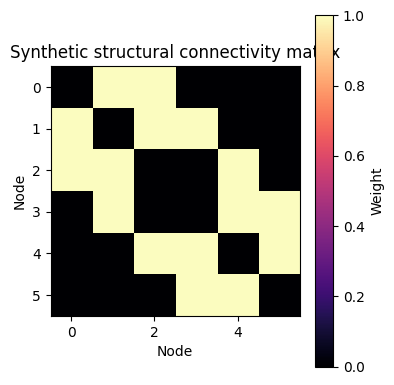

In [17]:
# -----------------------------
# Small synthetic test network
# -----------------------------

N = 6

W = np.array([
    [0, 1, 1, 0, 0, 0],
    [1, 0, 1, 1, 0, 0],
    [1, 1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1, 1],
    [0, 0, 1, 1, 0, 1],
    [0, 0, 0, 1, 1, 0],
], dtype=float)

W = W / W.max()

omega_hz = 10.0
omega = 2 * np.pi * omega_hz * np.ones(N)

fs = 250
t_total = 20.0
t_discard = 5.0
C = 1.0

z0 = random_initial_conditions(N, rng=42)

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(W, cmap="magma")
ax.set_title("Synthetic structural connectivity matrix")
ax.set_xlabel("Node")
ax.set_ylabel("Node")
plt.colorbar(im, ax=ax, label="Weight")
fig.tight_layout()

### Step 2: Generate synthetic empirical PLI

We simulate the model with **known ground-truth parameters** ($K_{\text{true}}$, $\lambda_{\text{true}}$), optionally add noise, and compute the resulting PLI matrix. This will serve as our "empirical" target for the fitting step.


In [18]:
# -----------------------------
# Generate synthetic empirical PLI
# -----------------------------

def generate_synthetic_empirical_pli(N, W, K_true, lam_true, C, omega, z0,
                                     t_total=20.0, t_discard=5.0, fs=250,
                                     noise_std=0.05, f_lo=8.0, f_hi=12.0):
    """
    Generate synthetic empirical PLI by:
    1. simulating the model with known parameters
    2. adding measurement noise
    3. filtering the noisy signals
    4. computing the PLI matrix
    """
    t, x, y = simulate_hopf(
        N=N, W=W, K=K_true, lam=lam_true, C=C,
        omega=omega, z0=z0,
        t_total=t_total, t_discard=t_discard, fs=fs,
    )

    noisy_x = x + noise_std * np.random.randn(*x.shape)
    filtered_x = bandpass_filter(noisy_x, fs=fs, f_lo=f_lo, f_hi=f_hi)
    pli_emp = compute_pli(filtered_x)

    return t, noisy_x, filtered_x, pli_emp

### Step 3: Run the synthetic simulation

We set the ground-truth parameters and generate the synthetic empirical PLI. The resulting signal and PLI matrix are visualised below.


Ground-truth parameters: K = 0.800, lambda = 1.000


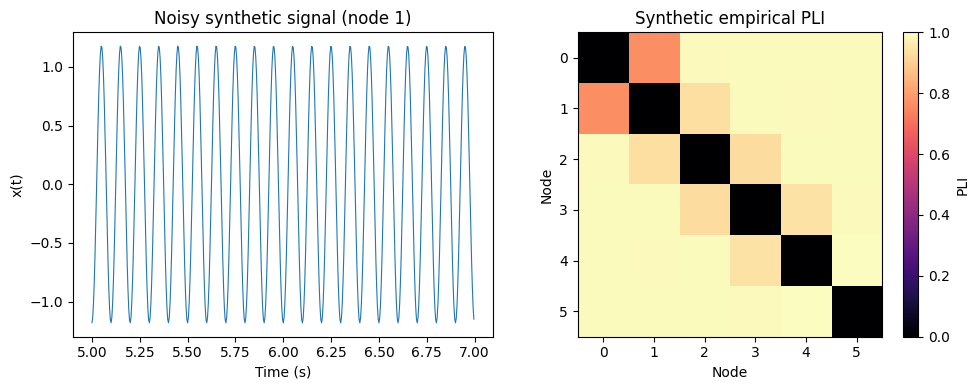

In [19]:
K_true = 0.8
lam_true = 1.0

t_emp, x_emp_noisy, x_emp_filt, pli_emp = generate_synthetic_empirical_pli(
    N=N, W=W, K_true=K_true, lam_true=lam_true, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
    noise_std=0,
)

print(f"Ground-truth parameters: K = {K_true:.3f}, lambda = {lam_true:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t_emp[:500], x_emp_noisy[0, :500], lw=0.8)
axes[0].set_title("Noisy synthetic signal (node 1)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x(t)")

im = axes[1].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[1].set_title("Synthetic empirical PLI")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

plt.colorbar(im, ax=axes[1], label="PLI")
fig.tight_layout()

### Step 4: Grid search to fit *K* and *λ*

We perform an exhaustive grid search over a range of *K* and *λ* values. For each parameter pair:
1. Simulate the network
2. Filter and compute PLI
3. Measure Pearson correlation with the synthetic empirical PLI

The parameter pair achieving the highest correlation is taken as the fitted estimate.


In [20]:
# -----------------------------
# Fit K and lambda by grid search
# -----------------------------

def fit_k_lambda_grid(N, W, pli_emp, K_values, lam_values, C, omega, z0,
                      t_total=20.0, t_discard=5.0, fs=250,
                      f_lo=8.0, f_hi=12.0):
    """
    Grid search over K and lambda.
    For each parameter pair:
    1. simulate the network
    2. filter the simulated signals
    3. compute simulated PLI
    4. compare simulated PLI to synthetic empirical PLI with Pearson correlation

    Returns
    -------
    corr_map : array, shape (len(K_values), len(lam_values))
    best_corr : float
    best_params : tuple (K_best, lam_best)
    best_pli : array, shape (N, N)
    """
    emp_vals = upper_triangle_values(pli_emp)

    corr_map = np.zeros((len(K_values), len(lam_values)))
    best_corr = -np.inf
    best_params = None
    best_pli = None

    for i, K in enumerate(K_values):
        for j, lam in enumerate(lam_values):
            t, x, y = simulate_hopf(
                N=N, W=W, K=K, lam=lam, C=C,
                omega=omega, z0=z0,
                t_total=t_total, t_discard=t_discard, fs=fs,
            )

            filtered_x = bandpass_filter(x, fs=fs, f_lo=f_lo, f_hi=f_hi)
            pli_sim = compute_pli(filtered_x)

            sim_vals = upper_triangle_values(pli_sim)
            corr, _ = pearsonr(emp_vals, sim_vals)

            corr_map[i, j] = corr

            if corr > best_corr:
                best_corr = corr
                best_params = (K, lam)
                best_pli = pli_sim.copy()

    return corr_map, best_corr, best_params, best_pli

### Step 5: Run the grid search

The recovered parameters should be close to the ground-truth values if the fitting procedure is working correctly.


In [21]:
K_values = np.linspace(0.1, 1.5, 15)
lam_values = np.linspace(-0.5, 2.0, 15)

corr_map, best_corr, best_params, best_pli = fit_k_lambda_grid(
    N=N, W=W, pli_emp=pli_emp,
    K_values=K_values, lam_values=lam_values,
    C=C, omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

print(f"True parameters:      K = {K_true:.3f}, lambda = {lam_true:.3f}")
print(f"Recovered parameters: K = {best_params[0]:.3f}, lambda = {best_params[1]:.3f}")
print(f"Best correlation:     r = {best_corr:.3f}")

True parameters:      K = 0.800, lambda = 1.000
Recovered parameters: K = 0.900, lambda = 1.286
Best correlation:     r = 0.998


### Step 6: Visualise the correlation landscape

The heatmap below shows the Pearson correlation as a function of *K* (y-axis) and *λ* (x-axis). A well-posed fitting problem should produce a clear, unimodal peak.

- ⚪ White circle: ground-truth parameter location
- ✖ Red cross: recovered (best-fit) location


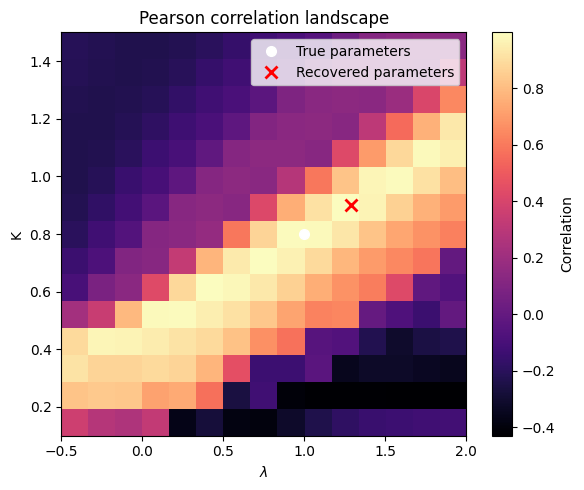

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    corr_map,
    origin="lower",
    aspect="auto",
    extent=[lam_values[0], lam_values[-1], K_values[0], K_values[-1]],
    cmap="magma",
)

ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("K")
ax.set_title("Pearson correlation landscape")

ax.plot(lam_true, K_true, "wo", ms=7, label="True parameters")
ax.plot(best_params[1], best_params[0], "rx", ms=8, mew=2, label="Recovered parameters")
ax.legend()

plt.colorbar(im, ax=ax, label="Correlation")
fig.tight_layout()

### Step 7: Scatter plots — simulated vs empirical PLI

Each point represents one pair of brain regions. The x-axis shows the synthetic empirical PLI value; the y-axis shows the simulated PLI for a given parameter combination.

A good fit produces points along the diagonal (slope ≈ 1, high Pearson r).


In [23]:
# -----------------------------
# Scatter plots: simulated vs empirical PLI
# -----------------------------

def plot_pli_scatter(pli_emp, pli_sim, title):
    emp_vals = upper_triangle_values(pli_emp)
    sim_vals = upper_triangle_values(pli_sim)
    r, _ = pearsonr(emp_vals, sim_vals)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(emp_vals, sim_vals, alpha=0.7)
    ax.set_xlabel("Synthetic empirical PLI")
    ax.set_ylabel("Simulated PLI")
    ax.set_title(f"{title}\nPearson r = {r:.3f}")

    lo = min(emp_vals.min(), sim_vals.min())
    hi = max(emp_vals.max(), sim_vals.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)

    fig.tight_layout()

**Best-fit parameters:** highest correlation recovered by grid search.


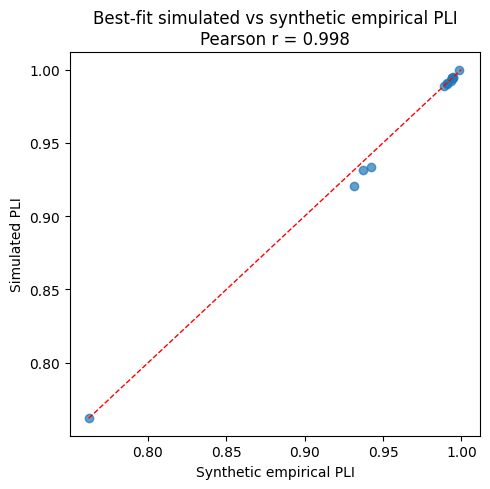

In [24]:
plot_pli_scatter(
    pli_emp, best_pli,
    title="Best-fit simulated vs synthetic empirical PLI"
)

**Poor-fit parameters:** deliberately chosen from the edge of the parameter grid to illustrate what a bad fit looks like.


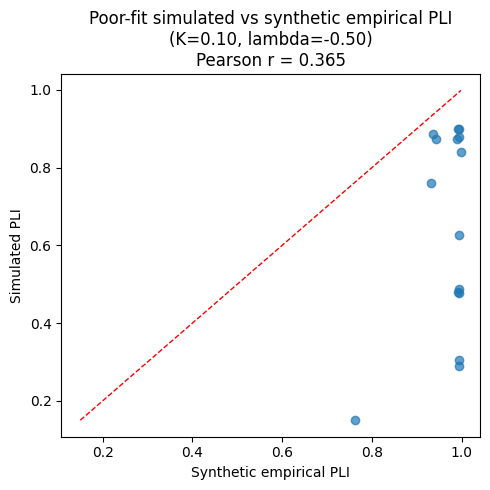

In [25]:
K_bad = K_values[0]
lam_bad = lam_values[0]

t_bad, x_bad, y_bad = simulate_hopf(
    N=N, W=W, K=K_bad, lam=lam_bad, C=C,
    omega=omega, z0=z0,
    t_total=t_total, t_discard=t_discard, fs=fs,
)

x_bad_filt = bandpass_filter(x_bad, fs=fs, f_lo=8.0, f_hi=12.0)
pli_bad = compute_pli(x_bad_filt)

plot_pli_scatter(
    pli_emp, pli_bad,
    title=f"Poor-fit simulated vs synthetic empirical PLI\n(K={K_bad:.2f}, lambda={lam_bad:.2f})"
)

### Step 8: PLI matrix comparison

Side-by-side visualisation of the synthetic empirical PLI, the best-fit simulated PLI, and a poor-fit simulated PLI.

> **Phase 1 complete.** If the recovered parameters are close to ground truth and the correlation landscape shows a clear peak, the fitting procedure is valid. We can now apply it to real empirical data.


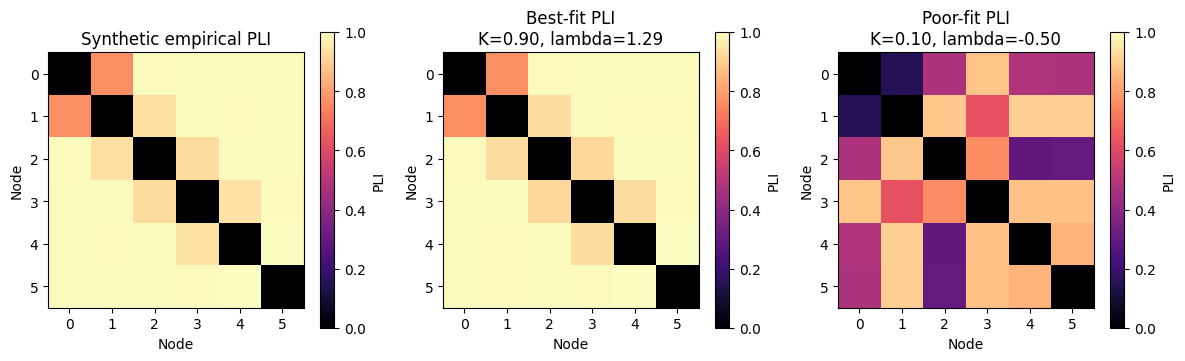

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(pli_emp, vmin=0, vmax=1, cmap="magma")
axes[0].set_title("Synthetic empirical PLI")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")

im1 = axes[1].imshow(best_pli, vmin=0, vmax=1, cmap="magma")
axes[1].set_title(f"Best-fit PLI\nK={best_params[0]:.2f}, lambda={best_params[1]:.2f}")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")

im2 = axes[2].imshow(pli_bad, vmin=0, vmax=1, cmap="magma")
axes[2].set_title(f"Poor-fit PLI\nK={K_bad:.2f}, lambda={lam_bad:.2f}")
axes[2].set_xlabel("Node")
axes[2].set_ylabel("Node")

plt.colorbar(im0, ax=axes[0], shrink=0.8, label="PLI")
plt.colorbar(im1, ax=axes[1], shrink=0.8, label="PLI")
plt.colorbar(im2, ax=axes[2], shrink=0.8, label="PLI")
plt.tight_layout()

---

## Phase 2 — Fitting to Real Empirical MEG Data

Now that the fitting procedure has been validated synthetically, we apply it to the real MEG-derived PLI matrices from:

- `control_PLI_raw.csv` — group-averaged PLI matrix for **healthy controls** (78 × 78)
- `glioma_PLI_raw.csv` — group-averaged PLI matrix for **glioma patients** (78 × 78)
- `structural_connectivity_matrix.csv` — structural connectivity matrix *W* (78 × 78, from diffusion MRI)
- `exp_frequencies.csv` — empirical peak frequencies per region, used to set node natural frequencies *ω*

### Procedure

For **each group** independently:
1. Load the empirical PLI matrix as the fitting target
2. Set node natural frequencies from `exp_frequencies.csv` (group mean per region)
3. Load the structural connectivity matrix *W*
4. Run the grid search over *K* and *λ*
5. Report the best-fit parameters and the Pearson correlation at the best fit
6. Visualise the correlation landscape and the PLI matrix comparison

### Scientific interpretation

| Parameter | Control interpretation | Glioma interpretation |
|-----------|------------------------|----------------------|
| $K$ (coupling) | Baseline global synchronisation | May be elevated due to tumour-driven network reorganisation |
| $\lambda$ (excitability) | Normal resting excitability | May be shifted by local hyperexcitability near the tumour |

Differences in fitted parameters between groups will reflect how glioma alters the **dynamical operating point** of the whole-brain network.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ── Load PLI matrices ──────────────────────────────────────────────────────────
pli_control = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\control_PLI_raw.csv", header=None).values.astype(float)
pli_glioma  = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\glioma_PLI_raw.csv",  header=None).values.astype(float)

# ── Load structural connectivity ───────────────────────────────────────────────
W_emp = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\structural_connectivity_matrix.csv", header=None).values.astype(float)

# ── Derive natural frequency from empirical data ───────────────────────────────
freq_df      = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\exp_frequencies.csv", index_col=0)
f_mean_hz    = float(freq_df.values.mean())          # grand mean across subjects & regions
omega_emp    = 2 * np.pi * f_mean_hz * np.ones(78)  # uniform for all 78 nodes

N_emp = 78
C_emp = 1.0

print(f"N regions     : {N_emp}")
print(f"Peak frequency: {f_mean_hz:.3f} Hz  →  ω = {omega_emp[0]:.4f} rad/s")
print(f"W range       : [{W_emp.min():.4f}, {W_emp.max():.4f}]")
print(f"PLI control   : [{pli_control.min():.4f}, {pli_control.max():.4f}]")
print(f"PLI glioma    : [{pli_glioma.min():.4f},  {pli_glioma.max():.4f}]")


N regions     : 78
Peak frequency: 8.472 Hz  →  ω = 53.2305 rad/s
W range       : [0.0000, 1.0000]
PLI control   : [0.0000, 0.0991]
PLI glioma    : [0.0000,  0.1168]


### Step 2: Visualise empirical PLI matrices

Before fitting, we inspect the empirical PLI matrices side-by-side to get a sense of the spatial pattern of functional connectivity in each group.


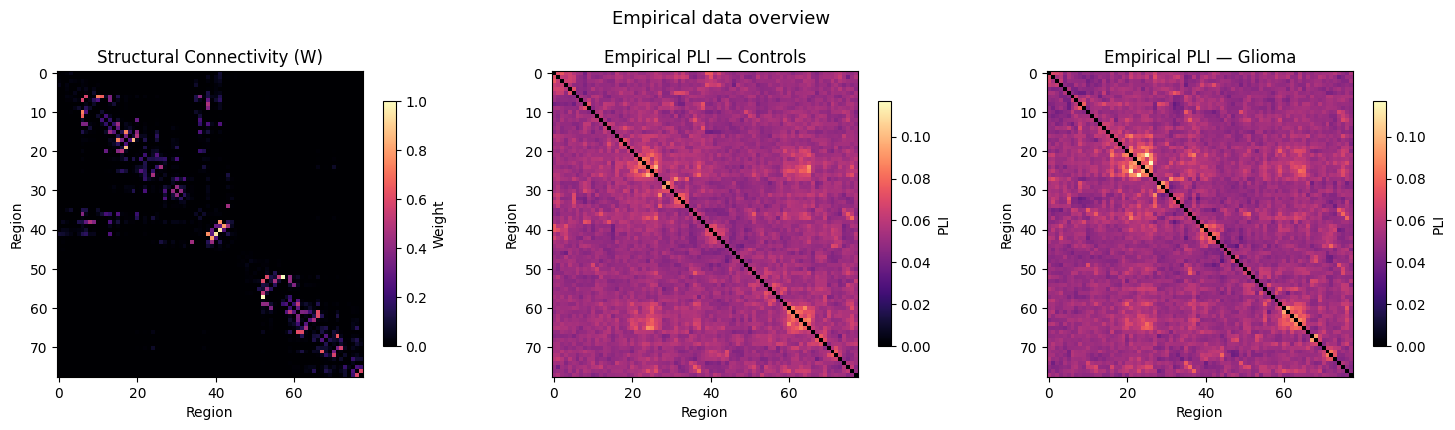

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vmax = max(pli_control.max(), pli_glioma.max())

im0 = axes[0].imshow(W_emp, cmap="magma")
axes[0].set_title("Structural Connectivity (W)")
axes[0].set_xlabel("Region"); axes[0].set_ylabel("Region")
plt.colorbar(im0, ax=axes[0], label="Weight", shrink=0.8)

im1 = axes[1].imshow(pli_control, vmin=0, vmax=vmax, cmap="magma")
axes[1].set_title("Empirical PLI — Controls")
axes[1].set_xlabel("Region"); axes[1].set_ylabel("Region")
plt.colorbar(im1, ax=axes[1], label="PLI", shrink=0.8)

im2 = axes[2].imshow(pli_glioma, vmin=0, vmax=vmax, cmap="magma")
axes[2].set_title("Empirical PLI — Glioma")
axes[2].set_xlabel("Region"); axes[2].set_ylabel("Region")
plt.colorbar(im2, ax=axes[2], label="PLI", shrink=0.8)

plt.suptitle("Empirical data overview", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### Step 3: Compare control vs glioma PLI

Before modelling, we quantify the similarity between the two empirical PLI matrices.  
A Pearson correlation significantly below 1 would suggest that glioma shifts the functional connectivity pattern — not just its amplitude.


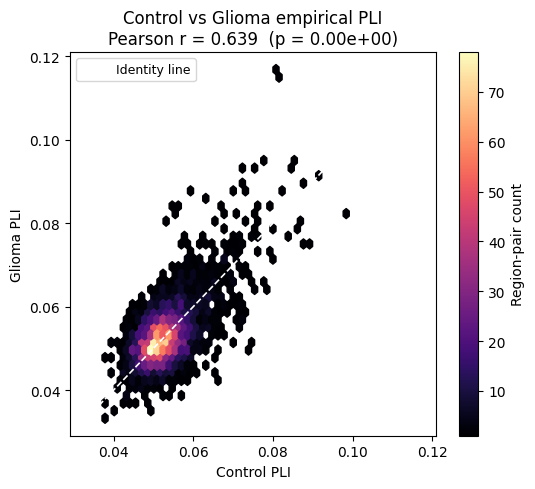

Pearson r between control and glioma PLI: 0.639


In [36]:
ctrl_vals = upper_triangle_values(pli_control)
glio_vals = upper_triangle_values(pli_glioma)
r_emp, p_emp = pearsonr(ctrl_vals, glio_vals)

fig, ax = plt.subplots(figsize=(5.5, 5))

# Hexbin: colour encodes point density
hb = ax.hexbin(ctrl_vals, glio_vals, gridsize=40, cmap="magma", mincnt=1)
plt.colorbar(hb, ax=ax, label="Region-pair count")

# Identity line
lo = min(ctrl_vals.min(), glio_vals.min())
hi = max(ctrl_vals.max(), glio_vals.max())
ax.plot([lo, hi], [lo, hi], "w--", lw=1.2, label="Identity line")

ax.set_xlabel("Control PLI")
ax.set_ylabel("Glioma PLI")
ax.set_title(f"Control vs Glioma empirical PLI\nPearson r = {r_emp:.3f}  (p = {p_emp:.2e})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Pearson r between control and glioma PLI: {r_emp:.3f}")


### Step 4: Grid search parameter space

We define the search grid for *K* and *λ*.

- **K** (global coupling): positive values; too low → disconnected dynamics, too high → over-synchronisation
- **λ** (local excitability): controls proximity to the Hopf bifurcation  
  - $\lambda < 0$ → damped (below bifurcation, noise-driven oscillations)  
  - $\lambda > 0$ → sustained limit cycle (above bifurcation)

The grid is intentionally coarse for a first pass. After identifying the best-fit region we can refine.

> ⚠️ **Runtime note:** with a 78-node network, each simulation takes several seconds.  
> A 15 × 15 grid = 225 simulations per group. Estimated total time: ~10–20 min depending on hardware.  
> Reduce grid resolution (e.g. `n_K = n_lam = 10`) for a faster exploratory run.


In [30]:
n_K   = 15
n_lam = 15

K_values_emp   = np.linspace(0.1, 2.0, n_K)
lam_values_emp = np.linspace(-1.0, 2.0, n_lam)

print(f"K   grid : {K_values_emp[0]:.2f} – {K_values_emp[-1]:.2f}  ({n_K} steps)")
print(f"λ   grid : {lam_values_emp[0]:.2f} – {lam_values_emp[-1]:.2f}  ({n_lam} steps)")
print(f"Total simulations per group: {n_K * n_lam}")


K   grid : 0.10 – 2.00  (15 steps)
λ   grid : -1.00 – 2.00  (15 steps)
Total simulations per group: 225


### Step 5a: Fit model to control group

We run the grid search using the control empirical PLI as the fitting target.  
The structural connectivity matrix and natural frequencies are the same for both groups — only the **target PLI** changes between groups.


In [31]:
# Random initial conditions seeded for reproducibility
z0_emp = random_initial_conditions(N_emp, rng=42)

print("Fitting model to CONTROL group...")
corr_map_ctrl, best_corr_ctrl, best_params_ctrl, best_pli_ctrl = fit_k_lambda_grid(
    N=N_emp, W=W_emp, pli_emp=pli_control,
    K_values=K_values_emp, lam_values=lam_values_emp,
    C=C_emp, omega=omega_emp, z0=z0_emp,
    t_total=30.0, t_discard=5.0, fs=250,
    f_lo=8.0, f_hi=12.0,
)

print(f"\n── Control best fit ──────────────────────")
print(f"  K      = {best_params_ctrl[0]:.3f}")
print(f"  λ      = {best_params_ctrl[1]:.3f}")
print(f"  r      = {best_corr_ctrl:.3f}")


Fitting model to CONTROL group...

── Control best fit ──────────────────────
  K      = 1.729
  λ      = -0.143
  r      = 0.060


### Step 5b: Fit model to glioma group

Same procedure, now targeting the glioma empirical PLI.


In [32]:
print("Fitting model to GLIOMA group...")
corr_map_glio, best_corr_glio, best_params_glio, best_pli_glio = fit_k_lambda_grid(
    N=N_emp, W=W_emp, pli_emp=pli_glioma,
    K_values=K_values_emp, lam_values=lam_values_emp,
    C=C_emp, omega=omega_emp, z0=z0_emp,
    t_total=30.0, t_discard=5.0, fs=250,
    f_lo=8.0, f_hi=12.0,
)

print(f"\n── Glioma best fit ───────────────────────")
print(f"  K      = {best_params_glio[0]:.3f}")
print(f"  λ      = {best_params_glio[1]:.3f}")
print(f"  r      = {best_corr_glio:.3f}")

print(f"\n── Group comparison ──────────────────────")
print(f"  ΔK = K_glioma - K_control = {best_params_glio[0] - best_params_ctrl[0]:+.3f}")
print(f"  Δλ = λ_glioma - λ_control = {best_params_glio[1] - best_params_ctrl[1]:+.3f}")


Fitting model to GLIOMA group...

── Glioma best fit ───────────────────────
  K      = 1.186
  λ      = -0.143
  r      = 0.087

── Group comparison ──────────────────────
  ΔK = K_glioma - K_control = -0.543
  Δλ = λ_glioma - λ_control = +0.000


### Step 6: Correlation landscapes

The heatmaps below show how well the model reproduces each group's PLI across the parameter space.  
A well-defined, unimodal peak indicates a stable, interpretable fit.  
Overlaying both best-fit points on the same landscape reveals how the two groups differ in parameter space.


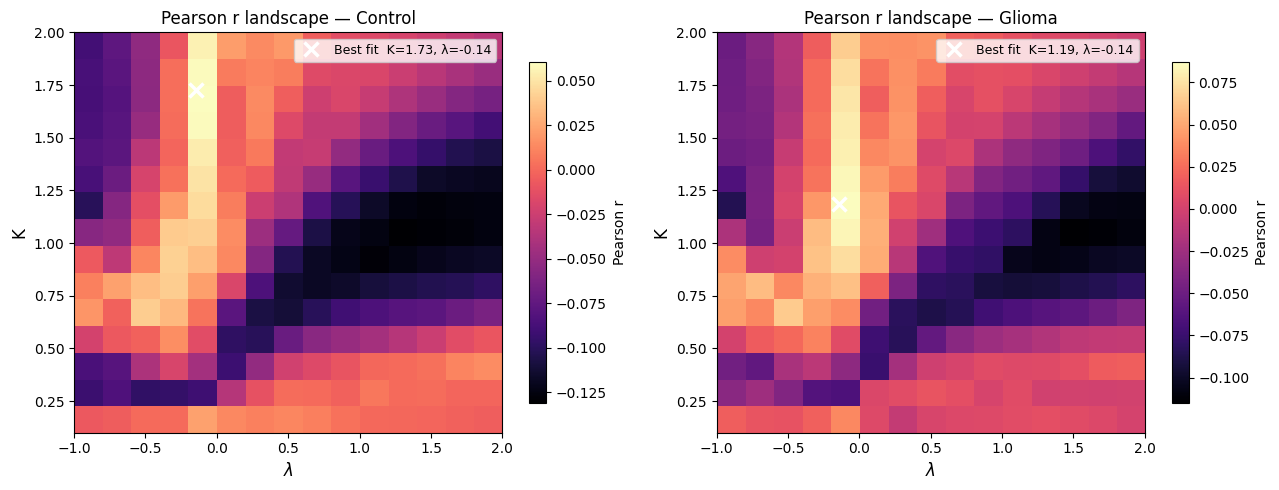

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cmap_data, best_p, title in [
    (axes[0], corr_map_ctrl, best_params_ctrl, "Control"),
    (axes[1], corr_map_glio, best_params_glio, "Glioma"),
]:
    im = ax.imshow(
        cmap_data,
        origin="lower", aspect="auto",
        extent=[lam_values_emp[0], lam_values_emp[-1],
                K_values_emp[0],   K_values_emp[-1]],
        cmap="magma",
    )
    ax.set_xlabel(r"$\lambda$", fontsize=12)
    ax.set_ylabel("K", fontsize=12)
    ax.set_title(f"Pearson r landscape — {title}", fontsize=12)
    ax.plot(best_p[1], best_p[0], "wx", ms=10, mew=2.5,
            label=f"Best fit  K={best_p[0]:.2f}, λ={best_p[1]:.2f}")
    ax.legend(fontsize=9)
    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.85)

plt.tight_layout()
plt.show()


### Step 7: Parameter space comparison

Plotting the best-fit locations of both groups on a shared landscape allows direct visual comparison of how glioma shifts the model's operating point.


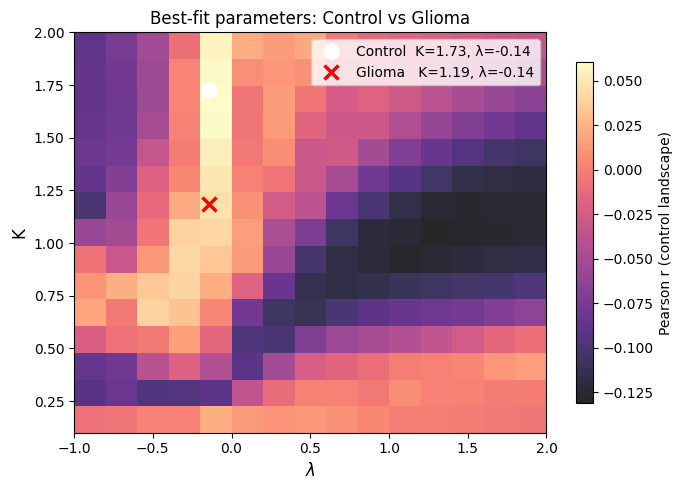

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))

# Use control landscape as background
im = ax.imshow(
    corr_map_ctrl,
    origin="lower", aspect="auto",
    extent=[lam_values_emp[0], lam_values_emp[-1],
            K_values_emp[0],   K_values_emp[-1]],
    cmap="magma", alpha=0.85,
)
plt.colorbar(im, ax=ax, label="Pearson r (control landscape)", shrink=0.85)

ax.plot(best_params_ctrl[1], best_params_ctrl[0],
        "wo", ms=10, mew=2, label=f"Control  K={best_params_ctrl[0]:.2f}, λ={best_params_ctrl[1]:.2f}")
ax.plot(best_params_glio[1], best_params_glio[0],
        "rx", ms=10, mew=2.5, label=f"Glioma   K={best_params_glio[0]:.2f}, λ={best_params_glio[1]:.2f}")

ax.set_xlabel(r"$\lambda$", fontsize=12)
ax.set_ylabel("K", fontsize=12)
ax.set_title("Best-fit parameters: Control vs Glioma", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Step 8: Simulated vs empirical PLI — scatter and matrix comparison

For each group, we compare the best-fit simulated PLI directly against the empirical PLI.

- **Scatter plot:** each point = one pair of brain regions. Good fit → points cluster along the diagonal.
- **Matrix plot:** visual comparison of spatial pattern. Good fit → similar structure (hotspots in same locations).


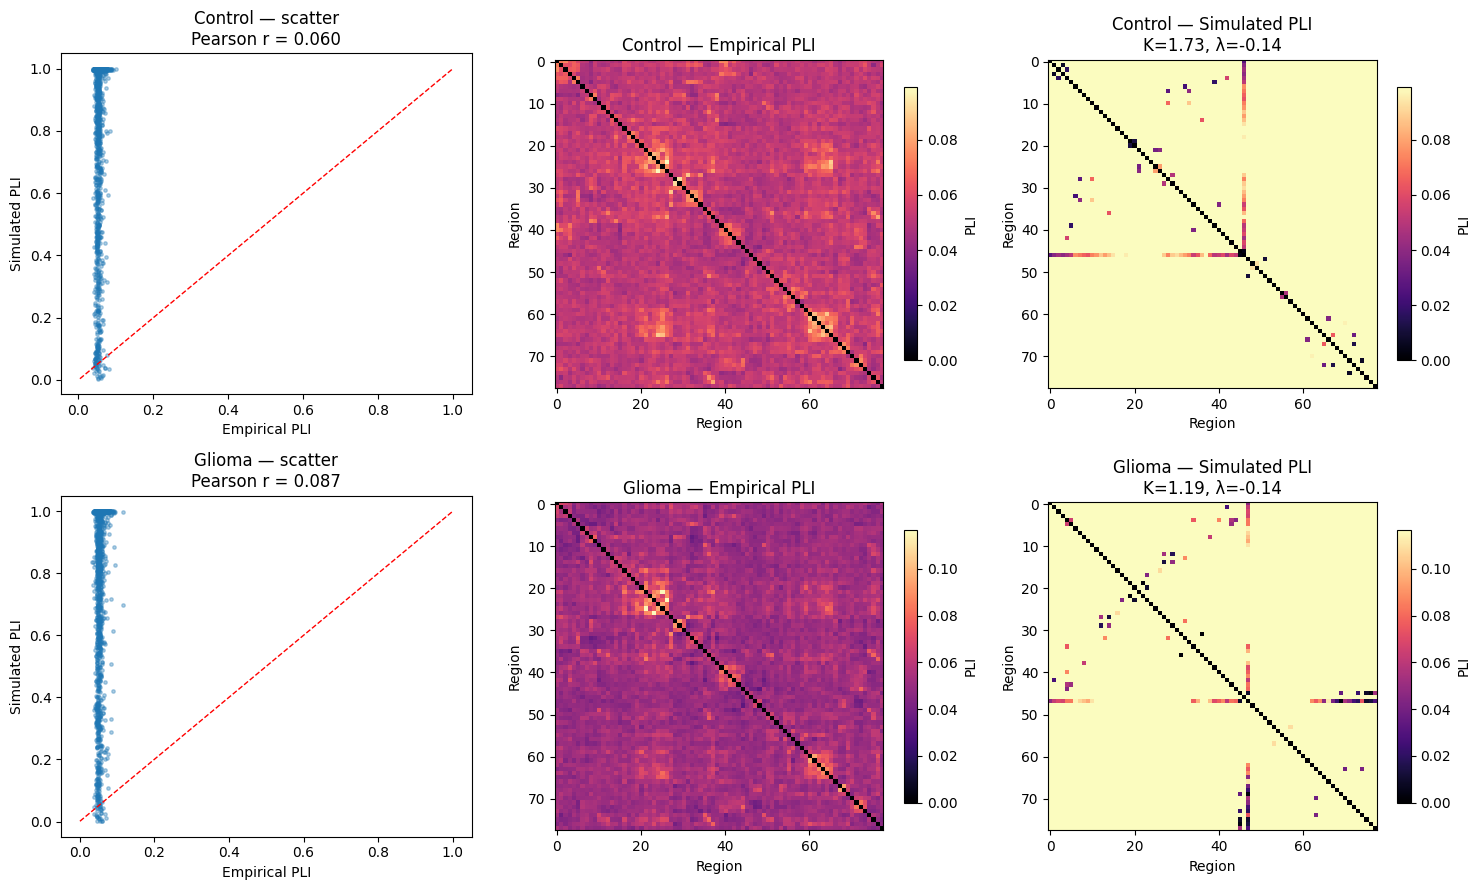

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

groups = [
    ("Control", pli_control, best_pli_ctrl, best_params_ctrl, best_corr_ctrl),
    ("Glioma",  pli_glioma,  best_pli_glio, best_params_glio, best_corr_glio),
]

for row, (label, pli_emp_g, pli_sim_g, best_p, best_r) in enumerate(groups):

    emp_vals = upper_triangle_values(pli_emp_g)
    sim_vals = upper_triangle_values(pli_sim_g)

    # Scatter
    axes[row, 0].scatter(emp_vals, sim_vals, alpha=0.35, s=6)
    lo = min(emp_vals.min(), sim_vals.min())
    hi = max(emp_vals.max(), sim_vals.max())
    axes[row, 0].plot([lo, hi], [lo, hi], "r--", lw=1)
    axes[row, 0].set_xlabel("Empirical PLI")
    axes[row, 0].set_ylabel("Simulated PLI")
    axes[row, 0].set_title(f"{label} — scatter\nPearson r = {best_r:.3f}")

    # Empirical PLI matrix
    vmax = pli_emp_g.max()
    im1 = axes[row, 1].imshow(pli_emp_g, vmin=0, vmax=vmax, cmap="magma")
    axes[row, 1].set_title(f"{label} — Empirical PLI")
    axes[row, 1].set_xlabel("Region"); axes[row, 1].set_ylabel("Region")
    plt.colorbar(im1, ax=axes[row, 1], label="PLI", shrink=0.8)

    # Simulated PLI matrix
    im2 = axes[row, 2].imshow(pli_sim_g, vmin=0, vmax=vmax, cmap="magma")
    axes[row, 2].set_title(f"{label} — Simulated PLI\nK={best_p[0]:.2f}, λ={best_p[1]:.2f}")
    axes[row, 2].set_xlabel("Region"); axes[row, 2].set_ylabel("Region")
    plt.colorbar(im2, ax=axes[row, 2], label="PLI", shrink=0.8)

plt.tight_layout()
plt.show()
